## 1. Network level lengths metrics

Reference: Chapter 7 and 10 of 'Networks' by Mark Newman, Chapter 17 of 'Introduction to the Modelling and Analysis of Complex Systems' by Hiroki Sayama.

### Shortest path length

Shortest length among all paths between any two nodes

In [1]:
import networkx as nx
nx.__version__

'3.2.1'

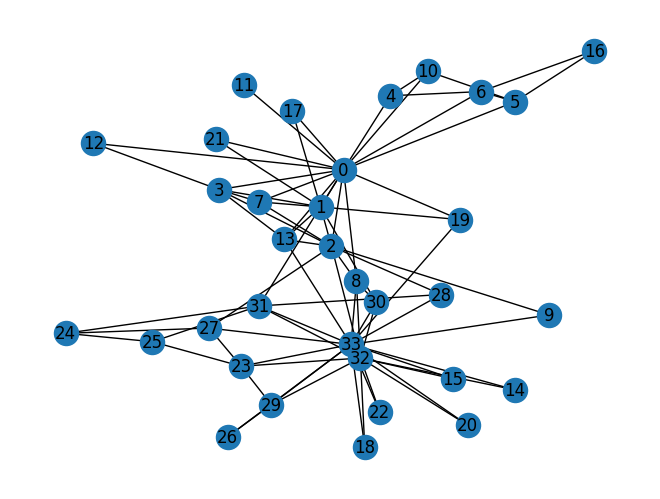

In [2]:
g = nx.karate_club_graph()
g.pos = nx.spring_layout(g)
nx.draw(g,g.pos, with_labels = True)

In [3]:
nx.shortest_path_length(g, 16, 25)

4

One can also get the shortest path between two nodes

In [4]:
nx.shortest_path(g, 16, 25)

[16, 5, 0, 31, 25]

Visualize this path

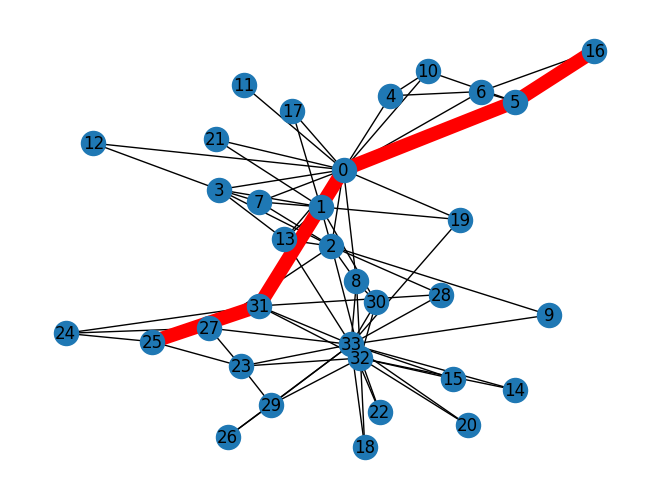

In [5]:
nx.draw(g,g.pos, with_labels = True)
path = nx.shortest_path(g, 16, 25)
edges = [(path[i], path[i+1]) for i in range(len(path) - 1)]

nx.draw_networkx_edges(g, g.pos, edgelist = edges,
                       edge_color = 'r', width = 10)

### Characteristic path length
$L=\dfrac{\sum _{ij}d_{ij} }{n( n-1)}$

where $d_{ ij}$ is the shortest path length between node $i$ and $j$.

This is an intuitive characterization of how big (or small) the network is.

In [6]:
nx.average_shortest_path_length(g)

2.408199643493761

### Eccentricity
$\varepsilon \left( i\right) =\max _{j}d_{ij}.$

This metric is defined for each node and gives the maximal shortest path length a node can have with any other node in the network. This tells how far the node is to the farthest point in the network.

In [7]:
nx.eccentricity(g)

{0: 3,
 1: 3,
 2: 3,
 3: 3,
 4: 4,
 5: 4,
 6: 4,
 7: 4,
 8: 3,
 9: 4,
 10: 4,
 11: 4,
 12: 4,
 13: 3,
 14: 5,
 15: 5,
 16: 5,
 17: 4,
 18: 5,
 19: 3,
 20: 5,
 21: 4,
 22: 5,
 23: 5,
 24: 4,
 25: 4,
 26: 5,
 27: 4,
 28: 4,
 29: 5,
 30: 4,
 31: 3,
 32: 4,
 33: 4}

### Diameter
$D=\max _{i}\varepsilon ( i)$

Maximal eccentricity of the network. This metric gives the maximal eccentricity in the network. Intuitively, it tells us how far any two nodes can get from one another within the network. Nodes whose eccentricity is $D$ are called peripheries.

In [8]:
nx.diameter(g)

5

In [9]:
nx.periphery(g)

[14, 15, 16, 18, 20, 22, 23, 26, 29]

### Radius
$R=\min _{i}\varepsilon (i)$

This metric gives the minimal eccentricity in the network. Intuitively, it tells us the smallest number of steps you will need to reach every node if you can choose an optimal node as a starting point. Nodes whose eccentricity is R are called centers.

In [10]:
nx.radius(g)

3

In [11]:
nx.center(g)

[0, 1, 2, 3, 8, 13, 19, 31]

## 2. Individual node centrality 
The eccentricity of nodes discussed above can be used to detect which nodes are most central in a network. This can be useful because, for example, if you send out a message from one of the center nodes with minimal eccentricity, the message will reach every single node in the network in the shortest period of time.

In the meantime, there are several other more statistically based measurements of node centralities, each of which has some benefits, depending on the question you want to study. Here is a summary of some of those centrality measures


* **Fun fact: The PageRank centrality measure is the secret sauce of Google, and it was worth $336 million dollars when sold in 2005. It is a very simple algorithm we will learn today.**

### Degree centrality
$C_d(i)=k_i/(n-1)$

Degree centrality is simply a normalized node degree, i.e., the actual degree divided by the maximal degree possible $(n -1)$. For directed networks, you can define in-degree centrality and out-degree centrality separately.

1. Twitter: higher follower counts means higher influence (higher out-degree)
1. Citation network: higher citation of a research paper means higher impact (higher in-degree)

In [12]:
nx.degree_centrality(g)

{0: 0.48484848484848486,
 1: 0.2727272727272727,
 2: 0.30303030303030304,
 3: 0.18181818181818182,
 4: 0.09090909090909091,
 5: 0.12121212121212122,
 6: 0.12121212121212122,
 7: 0.12121212121212122,
 8: 0.15151515151515152,
 9: 0.06060606060606061,
 10: 0.09090909090909091,
 11: 0.030303030303030304,
 12: 0.06060606060606061,
 13: 0.15151515151515152,
 14: 0.06060606060606061,
 15: 0.06060606060606061,
 16: 0.06060606060606061,
 17: 0.06060606060606061,
 18: 0.06060606060606061,
 19: 0.09090909090909091,
 20: 0.06060606060606061,
 21: 0.06060606060606061,
 22: 0.06060606060606061,
 23: 0.15151515151515152,
 24: 0.09090909090909091,
 25: 0.09090909090909091,
 26: 0.06060606060606061,
 27: 0.12121212121212122,
 28: 0.09090909090909091,
 29: 0.12121212121212122,
 30: 0.12121212121212122,
 31: 0.18181818181818182,
 32: 0.36363636363636365,
 33: 0.5151515151515151}

### Closeness centrality
$C_{c}\left( i\right) =\left( \dfrac{\Sigma_jd_{ij}}{n-1}\right) ^{-1}$

 It is a centrality score that measures the mean distance from a node to other nodes.
 Using data from the Internet Movie Database, the highest closeness centrality is 0.4143 for the actor Christopher Lee. This is an interesting result: Lee was neither as famous nor as successful as some of his contemporaries. He did, however, appear in an extraordinary number of films over the course of his long career—over 200 according to the database. This alone has a tendency to reduce his average distance to other nodes in the network by increasing the number of his collaborators and hence creating more paths through the network. Indeed we should, in general, expect nodes with higher degree to have shorter average distance to others, meaning that closeness centrality and degree centrality are positively correlated.

 Lee is perhaps best known for his role as the wizard Saruman in the film versions of The Lord of the Rings and The Hobbit.

In [13]:
nx.closeness_centrality(g)

{0: 0.5689655172413793,
 1: 0.4852941176470588,
 2: 0.559322033898305,
 3: 0.4647887323943662,
 4: 0.3793103448275862,
 5: 0.38372093023255816,
 6: 0.38372093023255816,
 7: 0.44,
 8: 0.515625,
 9: 0.4342105263157895,
 10: 0.3793103448275862,
 11: 0.36666666666666664,
 12: 0.3707865168539326,
 13: 0.515625,
 14: 0.3707865168539326,
 15: 0.3707865168539326,
 16: 0.28448275862068967,
 17: 0.375,
 18: 0.3707865168539326,
 19: 0.5,
 20: 0.3707865168539326,
 21: 0.375,
 22: 0.3707865168539326,
 23: 0.39285714285714285,
 24: 0.375,
 25: 0.375,
 26: 0.3626373626373626,
 27: 0.4583333333333333,
 28: 0.4520547945205479,
 29: 0.38372093023255816,
 30: 0.4583333333333333,
 31: 0.5409836065573771,
 32: 0.515625,
 33: 0.55}

### Betweenness centrality
$C_{b}\left( i\right) =\dfrac{1}{(n-1)(n-2)}\sum_{j\ne k, j\ne i,k\ne i}\dfrac{n^{i}_{jk}}{g_{jk}}$

where $n^{i}_{jk}$ is the number of shortest paths between $j$ and $k$ that pass through $i$, while ${g_{jk}}$ is the total number of shortest paths between $j$ and $k$.
It measures the probability that a node on shortest paths between other pairs of nodes. 

As an example of betweenness centrality, consider again the network of film actors from the previous section. It turns out that the individual with highest betweenness in this network is the great Spanish actor Fernando Rey, most famous in the English-speaking world for his 1971 starring role next to Gene Hackman in The French Connection. It is perhaps no coincidence that the highest betweenness belongs to an actor who appeared in both European and American films, played roles in several different languages, and worked extensively in both film and television, as well as on stage. Rey was the archetypal broker, a crucial link between different branches of the entertainment industry.

In the below diagram, group 1 is actors/actresses in the English movies, and group 2 is that of the Spanish movies. Node A is the actor Fernando Ray.

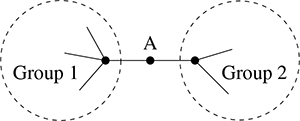

In [14]:
nx.betweenness_centrality(g)

{0: 0.43763528138528146,
 1: 0.053936688311688304,
 2: 0.14365680615680618,
 3: 0.011909271284271283,
 4: 0.0006313131313131313,
 5: 0.02998737373737374,
 6: 0.029987373737373736,
 7: 0.0,
 8: 0.05592682780182781,
 9: 0.0008477633477633478,
 10: 0.0006313131313131313,
 11: 0.0,
 12: 0.0,
 13: 0.04586339586339586,
 14: 0.0,
 15: 0.0,
 16: 0.0,
 17: 0.0,
 18: 0.0,
 19: 0.03247504810004811,
 20: 0.0,
 21: 0.0,
 22: 0.0,
 23: 0.017613636363636363,
 24: 0.0022095959595959595,
 25: 0.0038404882154882154,
 26: 0.0,
 27: 0.02233345358345358,
 28: 0.0017947330447330447,
 29: 0.0029220779220779218,
 30: 0.014411976911976909,
 31: 0.13827561327561325,
 32: 0.145247113997114,
 33: 0.30407497594997596}

### Eigenvector centrality
(Weighted importance by neighbors)

The name of this measure does not give an intuitive meaning to it, but a rather mathematical definition. The actual origin of this measure is the weighted sum of the centrality measures of its neighbors. 

"Eigenvector centrality is an extension of degree centrality that takes this factor into account. Instead of just awarding one point for every network neighbor a node has, eigenvector centrality awards a number of points proportional to the centrality scores of the neighbors."

We shall see how this leads to the mathematical notion of 'Eigenvector'

Assuming that the 'importance' of a node $i$ is $x_i$, and it is the sum of the importane of its neighbors. Then we have the relation:

$x_i=\alpha\sum_{j\textrm{ is a neighbor of }i}x_j$.

where $\alpha$ is a normalization constant. It turns out that the neighbors of $i$ can be captured by the adjacancy matrix elements, so the above equation simply becomes:

$x_i=\alpha\sum_{j=1}^nA_{ij}x_j$.

If we represent the importance of all ndoes as a vectore $\bm{x}$, then we have the following simple fomula:

$\bm{x}=\alpha\bm{Ax}$

And it so turns out that the $\bm{x}$ is a eigenvector of $\bm{A}$. 

However, there is more than one eigenvector ($n$ to be exact), so which one to choose? It turns out  the leading eigenvector of the adjacency matrix, i.e., the eigenvector corresponding to the largest (most positive) eigenvalue. This is because according to the Perron-Frobenius theorem, only the leading eigenvector has non-negative values for all of its elements: the centrality measure here requires a non-negative value to be meaningful.  

In [15]:
nx.eigenvector_centrality(g)

{0: 0.35548349418519426,
 1: 0.2659538704545024,
 2: 0.3171893899684447,
 3: 0.21117407832057056,
 4: 0.0759664588165738,
 5: 0.07948057788594245,
 6: 0.07948057788594245,
 7: 0.1709551149803543,
 8: 0.22740509147166046,
 9: 0.10267519030637756,
 10: 0.0759664588165738,
 11: 0.05285416945233646,
 12: 0.08425192086558085,
 13: 0.22646969838808145,
 14: 0.10140627846270832,
 15: 0.10140627846270832,
 16: 0.02363479426059687,
 17: 0.0923967566684595,
 18: 0.10140627846270832,
 19: 0.14791134007618667,
 20: 0.10140627846270832,
 21: 0.0923967566684595,
 22: 0.10140627846270832,
 23: 0.15012328691726787,
 24: 0.057053735638028055,
 25: 0.0592082025027901,
 26: 0.07558192219009324,
 27: 0.13347932684333308,
 28: 0.13107925627221215,
 29: 0.13496528673866567,
 30: 0.17476027834493088,
 31: 0.191036269797917,
 32: 0.3086510477336959,
 33: 0.37337121301323506}

For directed network the adjacancy matrix is not symmetric, so the definition of eigenvector centrality becomes more complex. It has two sets of eigenvectors: left and right. Depending on the meaning and context of the network, one of them could be more associated with 'importance' than the other. 

For wolrd wide web, the more web pages pointing to a particular page, means the more important this page is. This is associated with in degree. So in this case the right eigenvector makes sense:

$x_i=\alpha\sum_{j=1}^nA_{ij}x_j$.

For Twitter/X network, the more following of a person has, the more important it can be. This is associated with out-degree. Hence, the left eigenvector makes sense:

$x_i=\alpha\sum_{j=1}^nA_{ji}x_j$.

There is a key problem with the eigenvector definition: if a node that has only outgoing links, but not incoming links, then it would have 0 importance according to this measure. An example below:

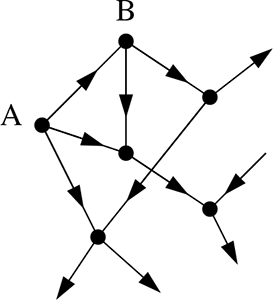

Node A in this case has importance 0. Further, node B has only incoming link from A, so it also has importance 0, so on and so forth. One typical network that would have 0 importance for all nodes is the citation network: since there is no cycles in the network, all nodes in the network will have 0 importance!!! The next measure is able so solve this.


### Katz centrality

The simple solution is the assume that every node has a default importance value $\beta$, in addition to whatever importance it carries from its neighbors. Mathematically this means:

$x_i=\alpha\sum_{j=1}^nA_{ij}x_j+\beta$

Again if we represent things as vector form:

$\bm{x}=\alpha\bm{Ax}+\beta\bm{1}$.

Since it is a linear equation, only the relative values between $\alpha$ and $\beta$ matter, so we can simply set $\beta=1$. So we have the following relation:

$\bm{x}=\alpha\bm{Ax}+\bm{1}$.

Unlike the eigenvector centrality measure which has no free parameters, Katz centrality measures requires the specification of the value $\alpha$. And it becomes immediately clear that $\alpha<\frac{1}{\lambda_{max}}$, where $\lambda_{max}$ is the maximal eigenvalue of the adjacancy matrix.

In [16]:
nx.katz_centrality(g)

{0: 0.3213245969592325,
 1: 0.2354842531944946,
 2: 0.2657658848154288,
 3: 0.1949132024917254,
 4: 0.12190440564948413,
 5: 0.1309722793286492,
 6: 0.1309722793286492,
 7: 0.166233052026894,
 8: 0.2007178109661081,
 9: 0.12420150029869696,
 10: 0.12190440564948413,
 11: 0.09661674181730141,
 12: 0.11610805572826272,
 13: 0.19937368057318847,
 14: 0.12513342642033795,
 15: 0.12513342642033795,
 16: 0.09067874388549631,
 17: 0.12016515915440099,
 18: 0.12513342642033795,
 19: 0.15330578770069542,
 20: 0.12513342642033795,
 21: 0.12016515915440099,
 22: 0.12513342642033795,
 23: 0.16679064809871574,
 24: 0.11021106930146936,
 25: 0.11156461274962841,
 26: 0.11293552094158042,
 27: 0.1519016658208186,
 28: 0.143581654735333,
 29: 0.15310603655041516,
 30: 0.16875361802889585,
 31: 0.19380160170200547,
 32: 0.2750851434662392,
 33: 0.3314063975218936}

In Katz centrality, even if the node's neighbors do not have high centrality, if the node has a lot of neighbors, it would have high centrality as well.

### PageRank

There is still one issue with Katz centrality measure: if a node is the neighbor of a high degree and high importance node, it tend to have high centrality. However this may not be true: a follower of an influencer on Twitter or Instagram does not mean he/she is influencial, yet Katz centrality tend to give high centrality to it. A simple workaround is to have the influencer's importance normalized by its degree when accounting for a follower's centrality measure, and this is what the PageRank algorithm looks like:


$x_i=\alpha\sum_{j=1}^nA_{ij}x_j/k_j+\sum_{j=1}^n \beta x_j/n$

Here rather than give a chance to stay at the same node $i$, PageRank assume uniform probability to visit any node in the network, including those who are not the neighbors of $i$.
Since only the relative values of $\alpha$ and $\beta$ matters here, one can set

$\beta=1-\alpha$,

and writing it as matrix form leads to:

$\bm{x}=\alpha\bm{AD^{-1}x}+(1-\alpha)\bm{x}/n$.

Again, the principal eigenvector represents the PageRank centrality. $\bm{D}$ is the diagonal matrix with elements $D_{ii}=k_i$. Similar to Katz centrality, the value of $\alpha$ is usually chosen to be $0.85$, and no particular reason is on the choice than that it works well.

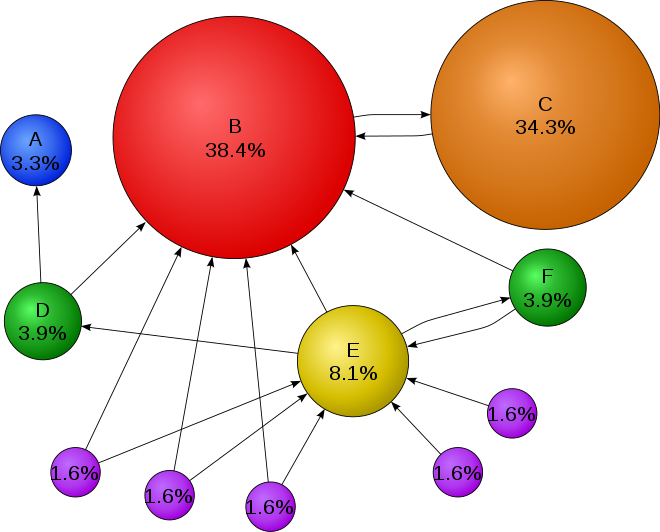

Image from Wikipedia

It was developed during the PhD of the Google founders, and the patent (belonging to Stanford University) was sold to Google at the value of $336 million in 2005.

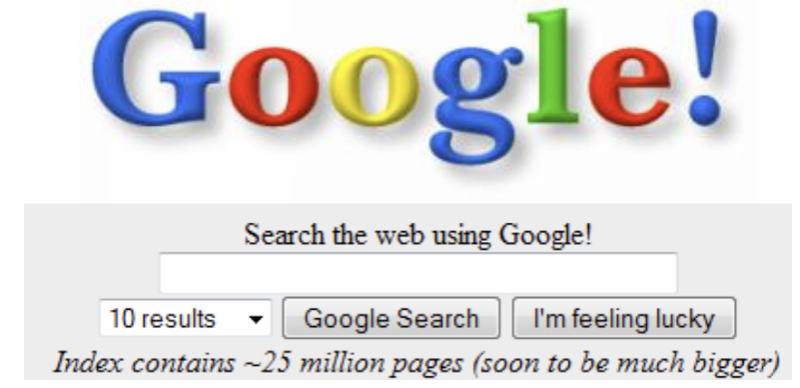

In [17]:
nx.pagerank(g)

{0: 0.08850807396280012,
 1: 0.057414840497110056,
 2: 0.06276686454603017,
 3: 0.03721208153631377,
 4: 0.020503977347501652,
 5: 0.03381044255357727,
 6: 0.03152901134345504,
 7: 0.026464618678806107,
 8: 0.03338155566846444,
 9: 0.009463219565799959,
 10: 0.020689016083505596,
 11: 0.009785686547904305,
 12: 0.011474872305945287,
 13: 0.033474187085322404,
 14: 0.012941600888556285,
 15: 0.01637633262359366,
 16: 0.016755401561857987,
 17: 0.009677265915396801,
 18: 0.009544864590131914,
 19: 0.013077518431081969,
 20: 0.011224235021037596,
 21: 0.01136015256356328,
 22: 0.01296059860686279,
 23: 0.04114596964602211,
 24: 0.01663437445025268,
 25: 0.028672962013730707,
 26: 0.015240392773380823,
 27: 0.027235358397633882,
 28: 0.01447852177427162,
 29: 0.028271813832825125,
 30: 0.02303184425091186,
 31: 0.04198548926127872,
 32: 0.07592643687005646,
 33: 0.09698041880501741}

### k-core

Another notion of groups is k-core. It is a description that tells you which nodes are on the peripheral of the network, which ones a more in the center. For regular structures like square grids, it is easy to tell which nodes are near the center core, but for complex networks it can be difficult. The coreness score is given to each node, such that a node with score $k$ has at least $k$ links with nodes of the same coreness score. The k-core of a network has huge impacts on the spreading phenomenon over the network.

One example of k-core can be the members of the World Economic Forum (WEF) - they are the global political and business leaders.

Note that here k-core refers to the group of nodes with the highest $k$ value, and they are the center most of the network. The detailed algorithm is as follows:
1. Let $k=0$.
1. Repeatedly delete all nodes whose degree is $k$ or less, until no such nodes exist. Those removed nodes are given a coreness $k$.
1. If there are still nodes remaining in the network, increase $k$ by 1, and then go back to the previous step.

An illustration is given below:

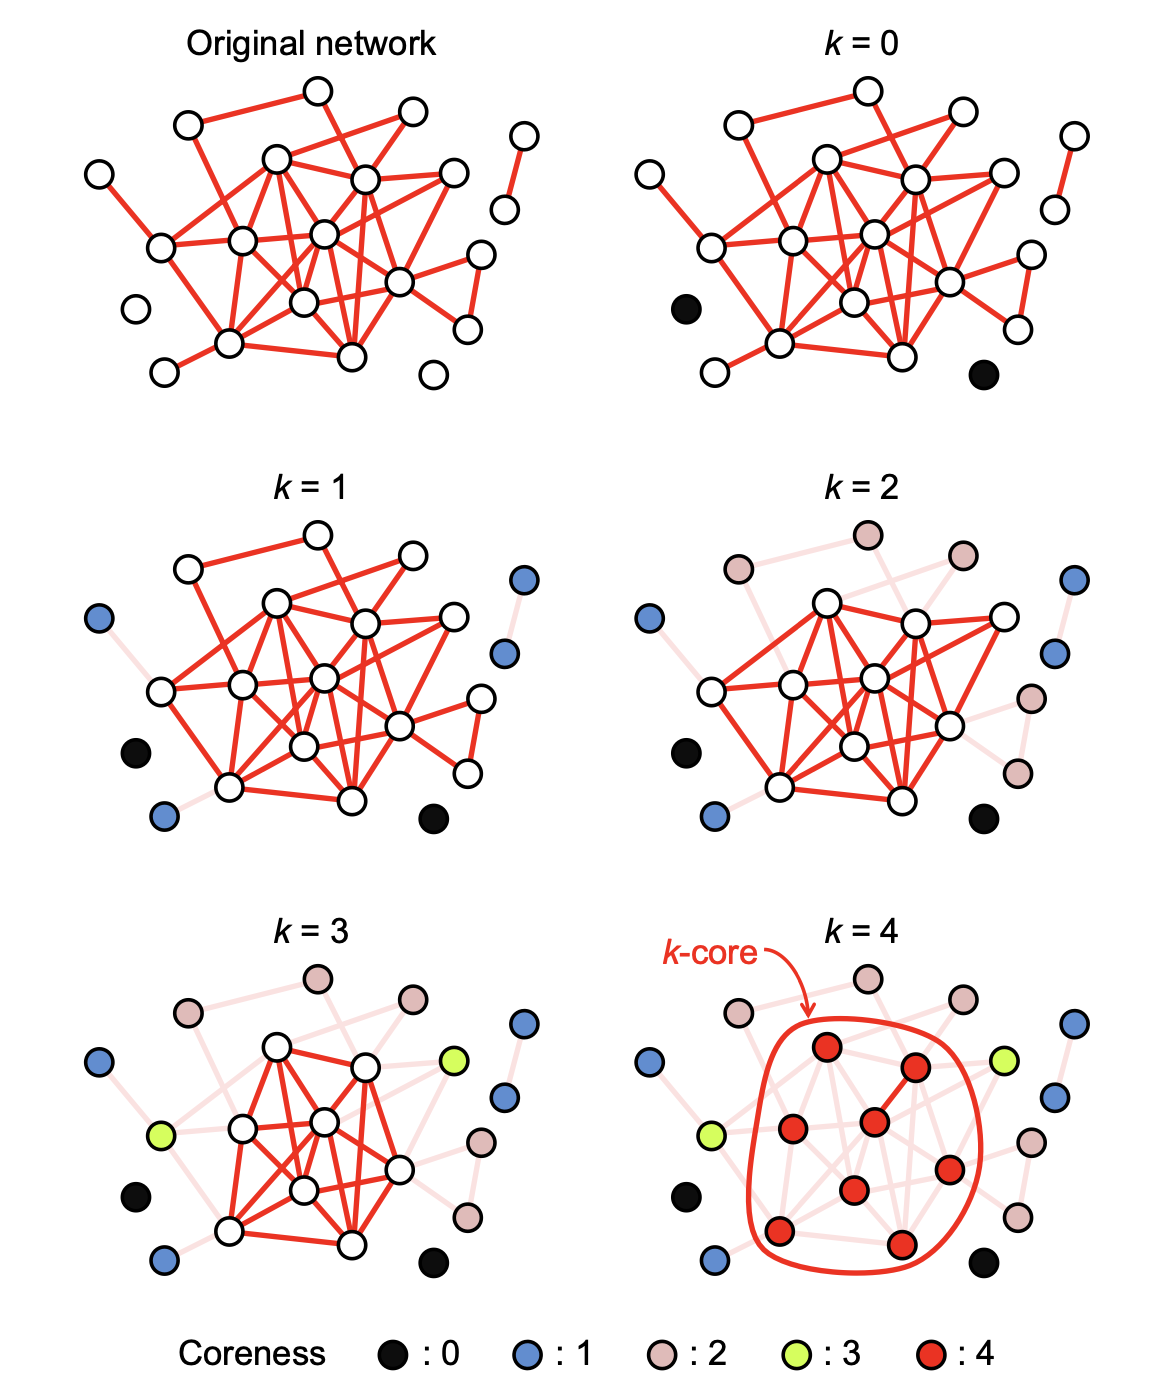

The coreness score can be found out simply using networkX:

In [18]:
nx.core_number(g)

{0: 4,
 1: 4,
 2: 4,
 3: 4,
 4: 3,
 5: 3,
 6: 3,
 7: 4,
 8: 4,
 9: 2,
 10: 3,
 11: 1,
 12: 2,
 13: 4,
 14: 2,
 15: 2,
 16: 2,
 17: 2,
 18: 2,
 19: 3,
 20: 2,
 21: 2,
 22: 2,
 23: 3,
 24: 3,
 25: 3,
 26: 2,
 27: 3,
 28: 3,
 29: 3,
 30: 4,
 31: 3,
 32: 4,
 33: 4}

And the k-core of the network can be visuallized below:

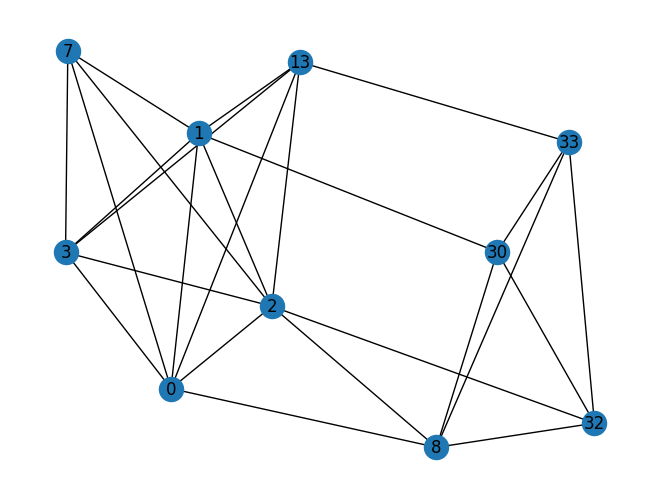

In [19]:
nx.draw(nx.k_core(g), with_labels = True)

## 3. Clustering related measures

### Clustering coefficient

This is about how well your friends know each other. Or alternatively, if two people are both your friends, how well they know each other? It can be written as:

$C(i)=\frac{|\{\{j,k\}| A_{ij}=A_{ik}=A_{jk}=1\}|}{k_i(k_i-1)/2}$

The denominator is the total mumber of pairs of friends $i$ has, and the numerator is the number of pair friends that know each other. As the name suggests, the higher is the clustering coefficient, the more clustered node $i$'s friends are.

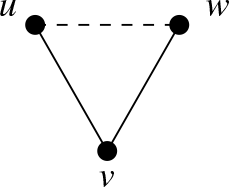

In [20]:
nx.clustering(g)

{0: 0.15,
 1: 0.3333333333333333,
 2: 0.24444444444444444,
 3: 0.6666666666666666,
 4: 0.6666666666666666,
 5: 0.5,
 6: 0.5,
 7: 1.0,
 8: 0.5,
 9: 0,
 10: 0.6666666666666666,
 11: 0,
 12: 1.0,
 13: 0.6,
 14: 1.0,
 15: 1.0,
 16: 1.0,
 17: 1.0,
 18: 1.0,
 19: 0.3333333333333333,
 20: 1.0,
 21: 1.0,
 22: 1.0,
 23: 0.4,
 24: 0.3333333333333333,
 25: 0.3333333333333333,
 26: 1.0,
 27: 0.16666666666666666,
 28: 0.3333333333333333,
 29: 0.6666666666666666,
 30: 0.5,
 31: 0.2,
 32: 0.19696969696969696,
 33: 0.11029411764705882}

One can calculate the average clustering coefficients of the whole network as a global property:

$C=\frac{1}{n}\sum_i C(i)$

In [21]:
nx.average_clustering(g)

0.5706384782076823

So the Karate club has more than 50% of friends know each other, quite a clustered network, and not surprising for a 'club'.

### Transitivity (another form of clustering)

Transitivity here means if $j$ is a friend of $i$ and $i$ is a friend of $k$, then $j$ is a friend of $k$. It is clear then this is closely related to the average clustering coefficient. And the mathematical definition is:

$C=\frac{|\{\{i,j,k\}| A_{ij}=A_{ik}=A_{jk}=1\}|}{|\{\{i,j,k\}| A_{ij}=A_{ik}=1\}|}$

In [22]:
nx.transitivity(g)

0.2556818181818182

This quantity is much smaller than the average clustering coefficient. Why?

### Assotative mixing

**Definitions**:

Assortativity (positive assortativity) - The tendency for nodes to connect to other
nodes with similar properties within a network.

Disassortativity (negative assortativity) - The tendency for nodes to connect to other
nodes with dissimilar properties within a network.

Assortativity coefficient:

$r=\dfrac{\sum _{(i,j)\in E}\left( f\left( i\right) -\overline{f_1}\right) \left( f(j)-\overline{f_2}\right) }{
\sqrt{\sum _{(i,j)\in E}\left( f(i)-\overline {f_{1}}\right)^2} \sqrt{\sum _{(i,j)\in E}\left( f(j)-\overline{f_{2}}\right)^2}}$

where $E$ is the set of directed edges (undirected should appear twice in $E$ in two directions), and

$\overline{f_{1}}=\frac{\sum _{(i,j)\in E}f\left( i\right)}{|E|},\ \overline{f_{2}}=\frac{\sum _{(i,j)\in E}f\left( j\right)}{|E|}$.

It can be seen that the assortativity coefficient is a Pearson correlation coefficients on certain node property $f$ between each pair of nodes. Positive means similar nodes connect, while negative means dis-similar nodes connect.



One commonly used property is the degree of nodes. In such a case the assortativity coefficients is the degree-degree correlation of the nodes. Here is an illustration. (a) is assortative and (b) is dissortative.

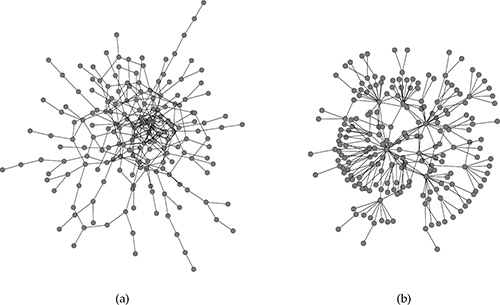

We can calculate the assortativity coefficient of a Barabasi-Albert Network. And it turns out the it is slightly negative. Why?

In [23]:
n = 1000
ba = nx.barabasi_albert_graph(n, 5)
nx.degree_assortativity_coefficient(ba)

-0.06479038189136735

### Example on political networks.
A study has looked at assortativity of the US politician networks, where the links represent voting on the same legislations. Blue nodes are members of the Democratic Party, and red nodes are members of the Republican party. You can see how the assortativity changes over the years.

Source: https://doi.org/10.1371/journal.pone.0123507, Andris, Clio, et al. "The rise of partisanship and super-cooperators in the US House of Representatives." PloS one 10.4 (2015): e0123507.

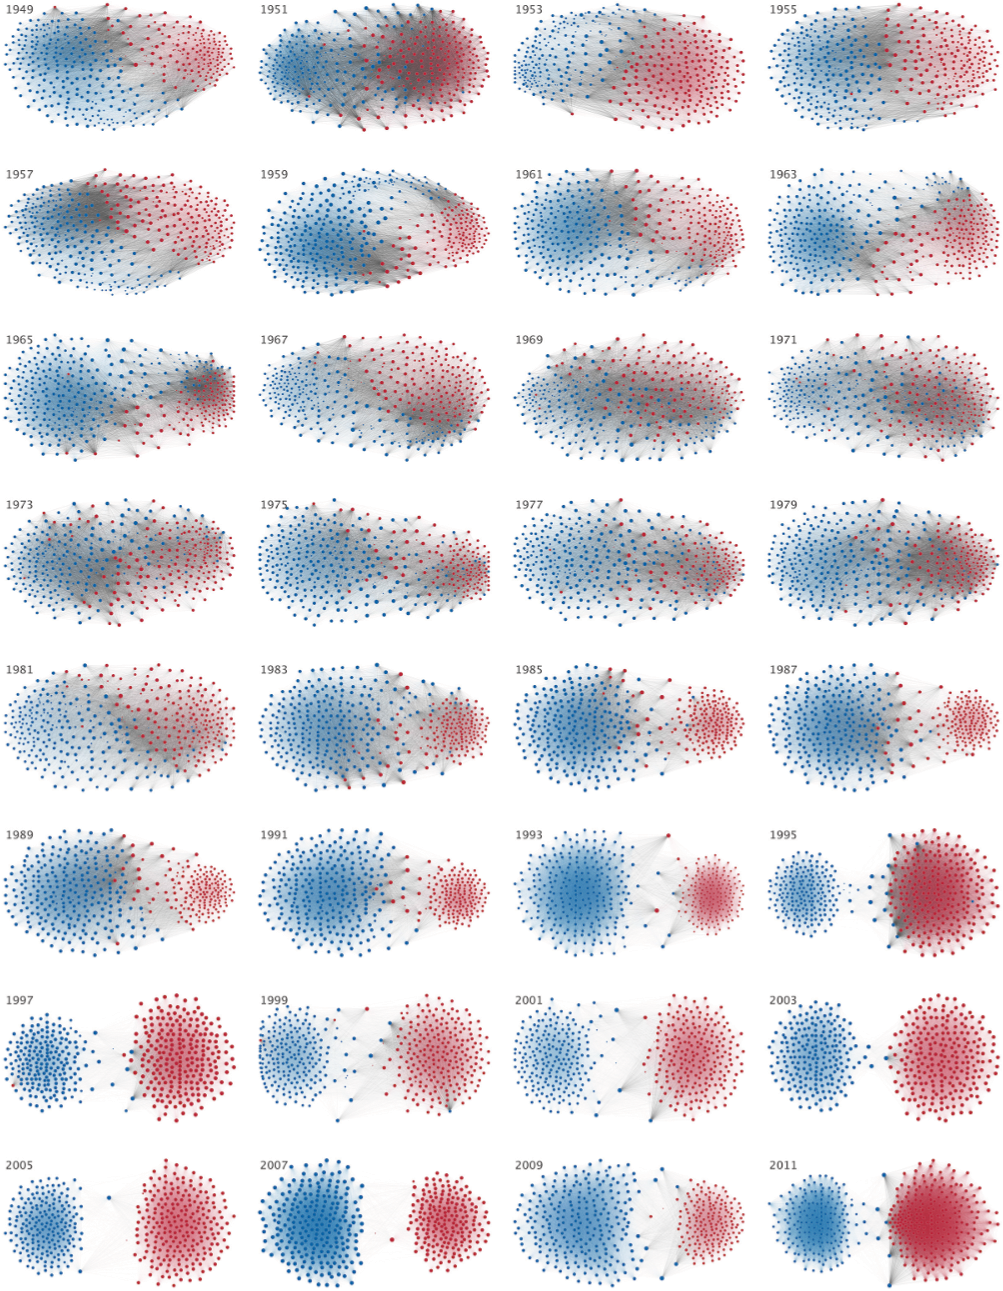

## 4. Community structure and modularity

**Community** A set of nodes that are connected more densely to each other than to the rest of the network. Communities may or may not overlap with each other, depending on their definitions.

**Modularity** The extent to which a network is organized into multiple communities.

$Q=\frac{|E_{in}|-\langle |E_{in}|\rangle}{|E|}$

where $|E|$ is the total number of edges, $|E_{in}|$ is the number of intra-community edges, i.e. edges within communities, and $\langle|E_{in}|\rangle$ is the number of intra-community edges if the network is purely random. By this definition of modularity, higher $Q$ values means higher community structure.

Community can be a group of nodes that are closely connected with each other. Sometimes it is pre-defined like racial groups - Chinese, Malay and Indian communities in Singapore for instance. Sometimes it is unknown, and there exists many different algorithms to detect the communities. An example here:

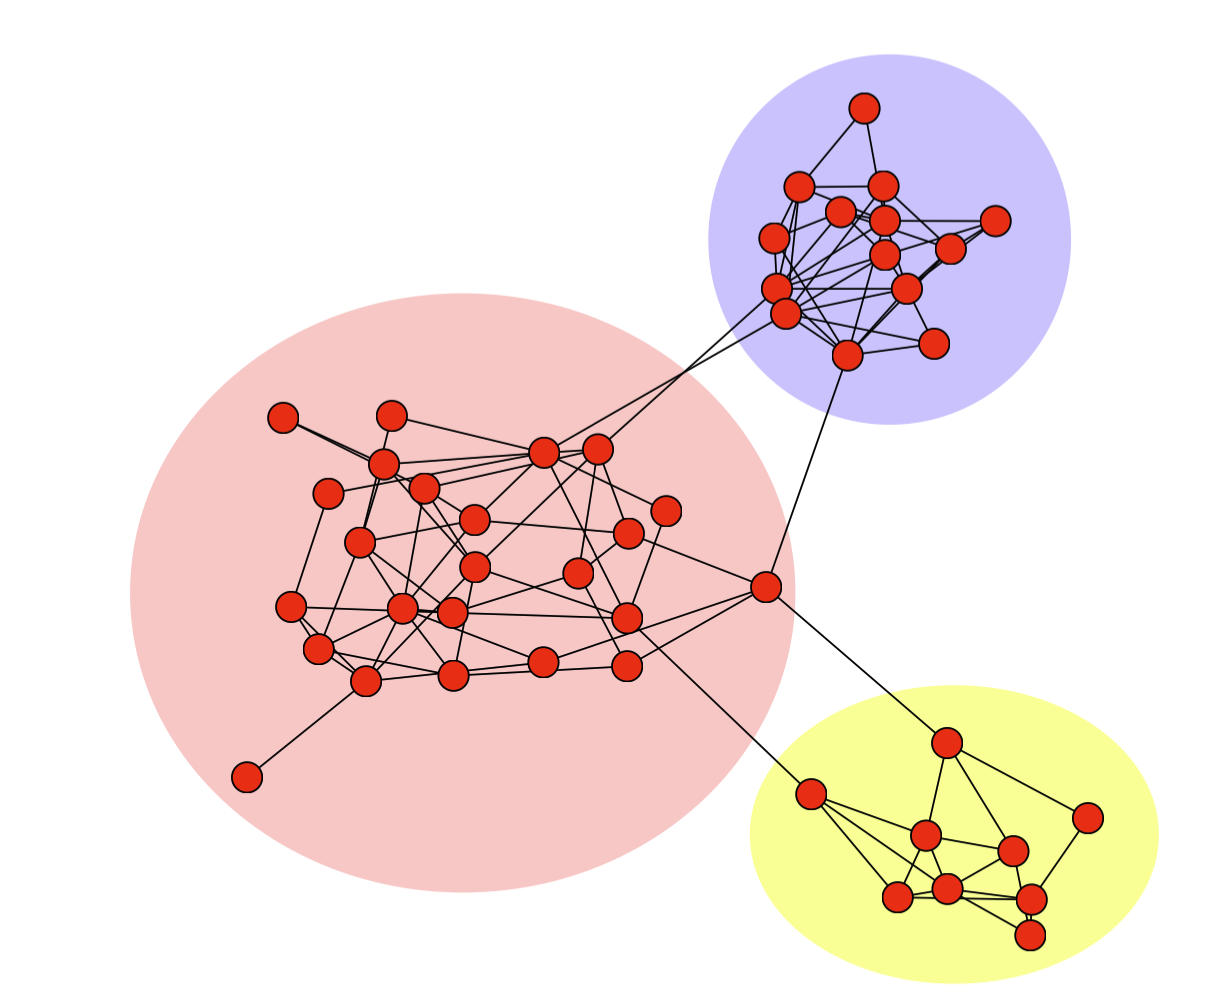

In a way, community dectection algorithms are machine learning algorithms, specifically classification algorithms: you try to classify each node into different communities (categories). And this is a big field of its own. There are many methods developed in network science, while the latest progress in graph neural networks have accelerated the development as well.

Here is one example using the Louvain method to find communities:

In [24]:
communities = nx.community.louvain_communities(g)
list(communities)

[{0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21},
 {4, 5, 6, 10, 16},
 {8, 9, 14, 15, 18, 20, 22, 26, 29, 30, 32, 33},
 {23, 24, 25, 27, 28, 31}]

## 5. Giant component

Very large connected component in the network?

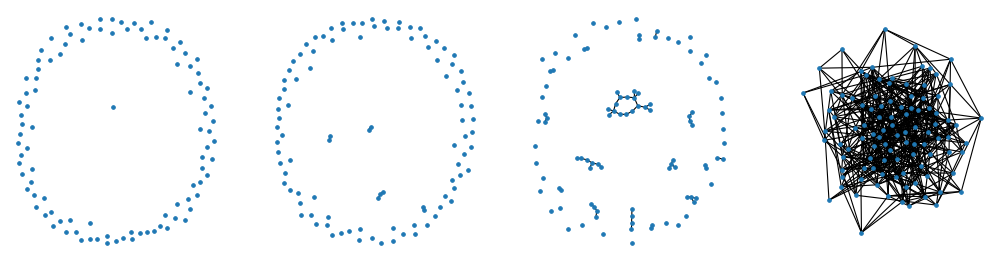

In [25]:
from matplotlib import pyplot as plt
plt.figure(figsize=(16, 4), dpi=80)
for i, p in [(1, 0.0001), (2, 0.001), (3, 0.01), (4, 0.1)]:
    plt.subplot(1, 4, i)
    #title('p = ' + str(p))
    g = nx.erdos_renyi_graph(100, p)
    nx.draw(g, node_size = 10)


## 6. Real network structures

The properties measured are: type of network, directed or undirected; 
1. total number of nodes $n$;
1. total number of edges $m$; 
1. average degree $c$; 
1. fraction of nodes in the largest (giant) component $S$; 
1. characteristic path length (mean distance between connected node pairs) $l$; 
1. exponent $\alpha$ of the degree distribution if the distribution follows a power law (or “-” if not; in/out-degree exponents are given for directed networks); 
1. transitivity $C$ (or global clustering coefficient);
1. average clustering coefficient $C_{WS}$; 
1. and the degree correlation (degree assortativity) coefficient $r$. 

### Social networks

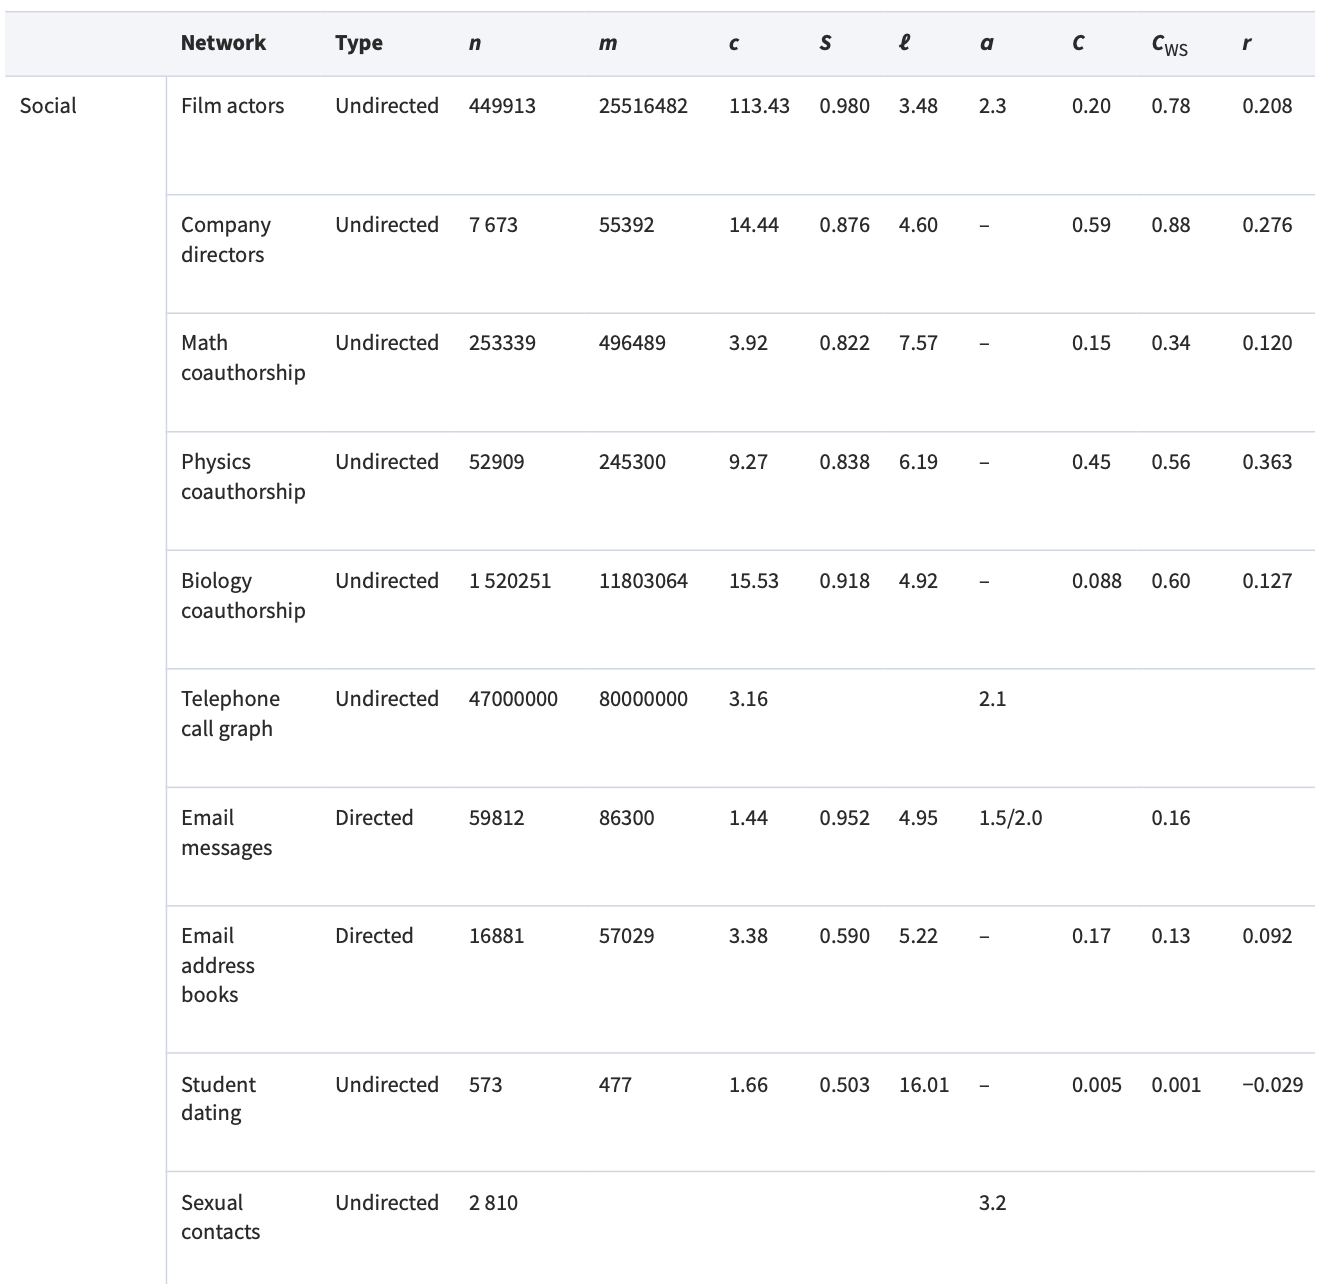

### Small world property

Most social networks have very short characteristic path length $l$, and are usually called small world phenomenon. This is well-known from the Milgram experiment letter passing, where 6 passes of letters can reach almost anyone in the world.

Such small world property of social networks explains the fast spreading of information and diseasees.

### Assortative

Many social networks are assortative ($r>0$), a natural phenonemon as people tend to make friends with people similar to themselves.

### High clustering coefficient

Highest is from 'company directors' network, in which many such top executives know each other. It is a close community where people either know each other or at least heard of each other.

### Power-law distribution

Also called scale free with $1<\gamma<3$. No variance.


### Information networks

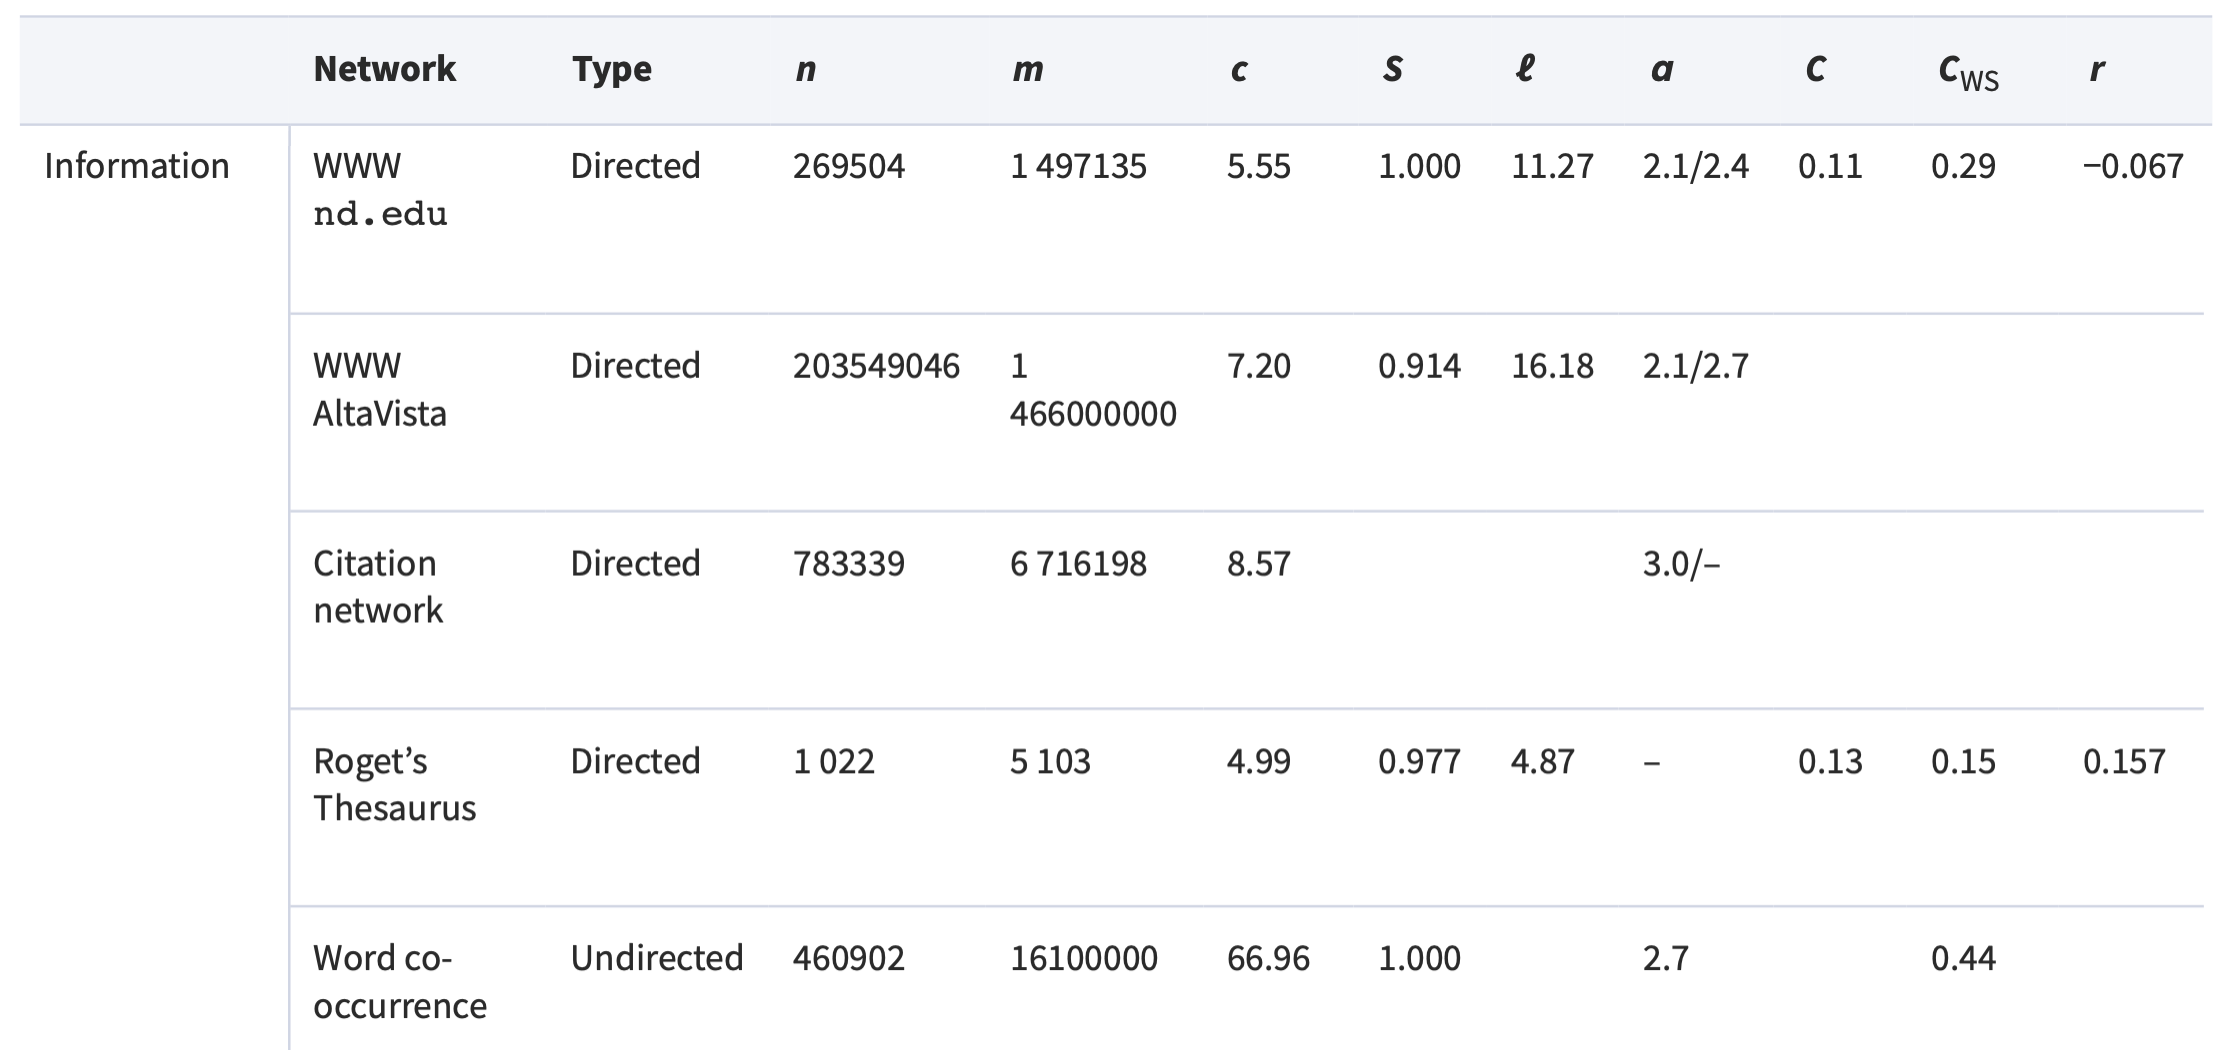

### Small world and Scale-free

### Biological networks

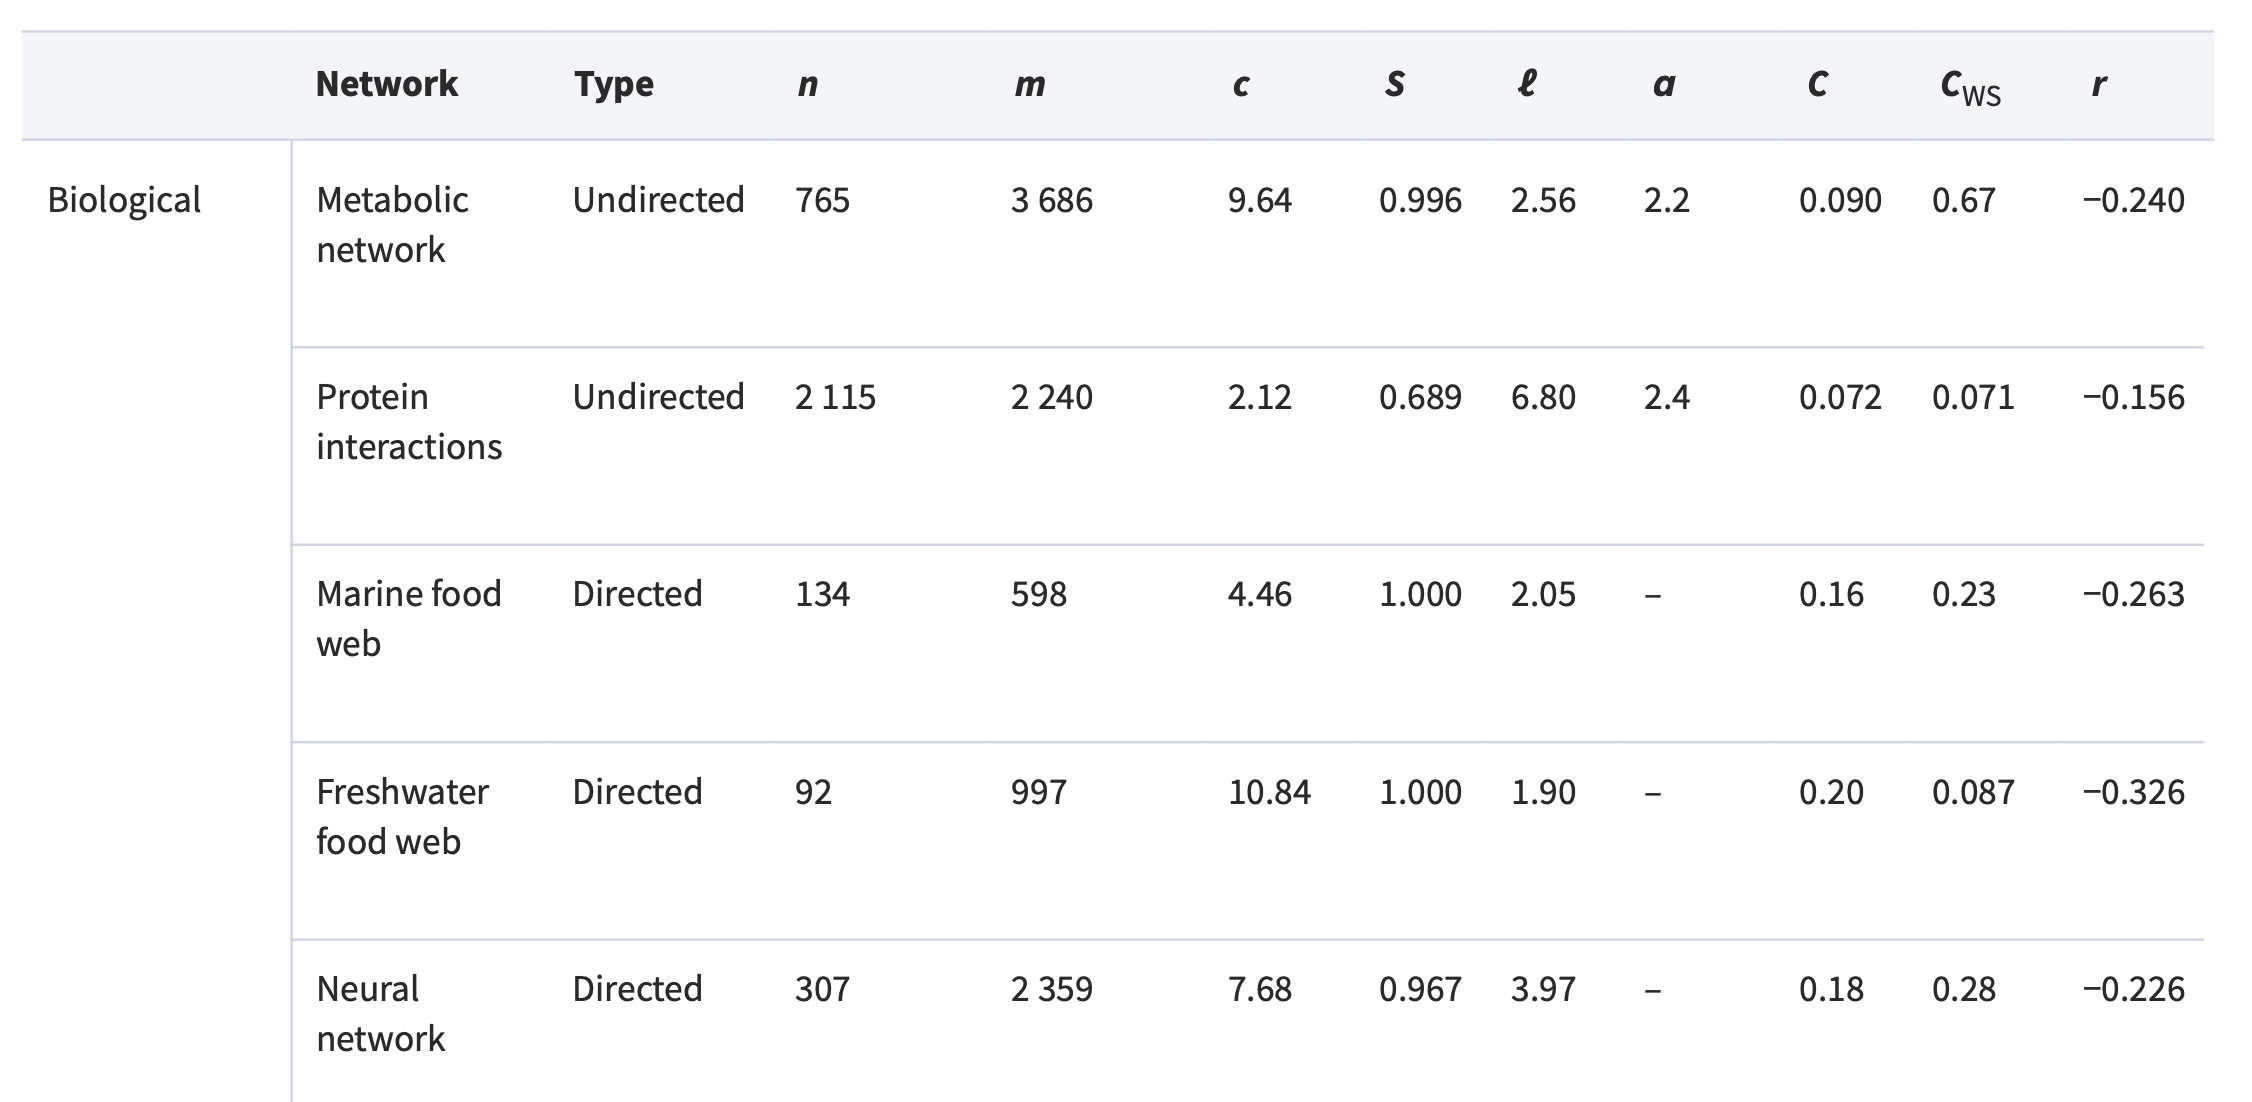

### Small world 

It is actually not surprising. If a network has random connections, the small-world naturally occurs as we shall prove later.

### Dissasortative

Biological networks are dissortative, and such property helps making it resilient. It also has something to do with the functional groups of the networks.

## 7. Computational Complexity

Due the gigantic sizes of real world networks, computational time could be a serious problem, sometimes making certain analysis/simulations infeasible even on modern computer clusters. Computational complexity is a way to have rough estimate on the order of the computational steps in a computer code.

The 'order' here refers to the polynomial order of the network size '$n$' and '$m$'. If a code takes computatonal steps proportional to '$n$', then we say the complexity is $O(n)$. If the number of steps are proportional to '$n^2$', then the complexity is $O(n^2)$. 

For example, to find out the degree of a node $i$, you need to look for each neighbor of $i$, so the computational steps is proportional to the average degree $c$. Since $c$ is a constant independend of network size, we say the computational complexity is $O(1)$.

In most networks, the network is sparse, so the total number of edges $m$ is a constant multiple of $n$. Hence, the computational complexity is usually of the same order in both $n$ and $m$.

**Question: What is the computational complexity to find out the average degere?**

### Special algorithm: Breadth first search

This can be used to find the shortest path between a pair of nodes. 

"The algorithm works by assigning numbers to nodes one by one, indicating their distance from node $s$. Initially node $s$ is assigned distance $0$ and all other nodes are unassigned. Then, for each integer value of $d$ from $0$ upward, we locate all nodes with distance $d$, find their neighbors, and mark any that currently have no assigned distance as having distance⁠. The algorithm ends when there are no nodes with the next value of $d$."

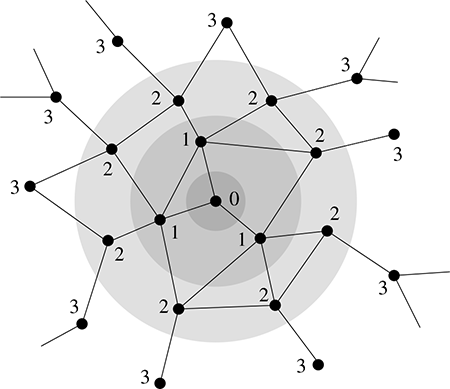

**What is the computatonal complexity of finding the distance between two nodes?**

**What is the computational complexity of finding the shortest distances between node $i$ and all other nodes?**

**What is the computational complexity of finding the eccentricity of node $i$?**